# Section: Hyperbola Fitting to Estimate Velocity

In the figure given in the paper we essentially overlap a bunch of point reflectors to simulate a contact and finite-impedance reflectors (the tapering), depite the homogenous velocity medium. This gives the illusion of a more realistic hyperbola. This notebook will cover our hyperbola fitting workflow, thresholding-->c3-->smooth path algorithm--> hyperbolic template

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../..')

from SimulatingGPR import gprsim

/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/hyperbola_fitting_to_estimate/../../SimulatingGPR/gprsim.py:384: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if alpha is 'abc123':
/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Make a terribly Noisy Simulation

total x meters: 70, total t depth: 1e-06, Numbler of x steps (scans): 70, how many samples in time domain: 1000


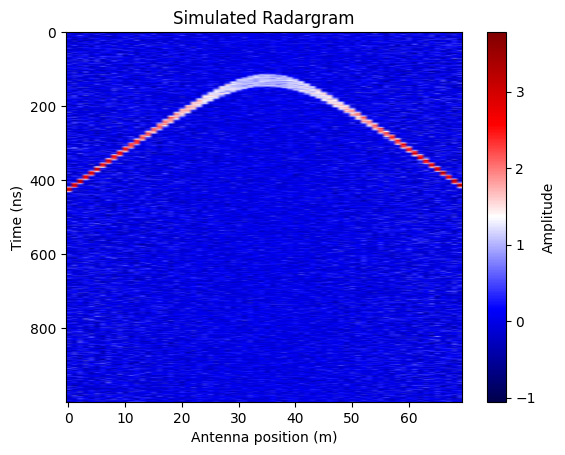

In [7]:
# Parameters
eps_r = 3                  # relative dielectric permittivity
rf = 300e6                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
region_shape = (70, 1e-6)  # grid (x,z)
SNR = 1
wavetype = 'gaussian'

# Point reflectors at (x,z) where x [m] and z [m]
reflectors = [(35, 10), (35, 10.5), (35, 11), (35, 11.5), (35, 12), (35, 12.5)]
data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR)

plt.imshow(data.T, aspect='auto', cmap='seismic')
plt.xlabel("Antenna position (m)")
plt.ylabel("Time (ns)")
plt.title("Simulated Radargram")
plt.colorbar(label="Amplitude")
plt.show()